# World Happiness Report — Exploratory Data Analysis

**Course:** ETL (G01) — Workshop 3  
**Objective:** Analyze 5 years of World Happiness data (2015–2019), identify schema differences, clean and harmonize into a unified dataset, and prepare for feature engineering and ML modeling.

> This notebook covers **Steps 1 & 2** of the workshop: EDA + Data Cleaning and Harmonization.


## 1. Setup

Import all required libraries and configure paths.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import warnings
warnings.filterwarnings('ignore')

# Use a consistent style
plt.style.use('ggplot')
sns.set_palette("Set2")

# Path to raw data (notebook is in notebooks/, data is in data/raw/)
DATA_PATH = "../data/raw"

print("Setup complete.")


Setup complete.


## 2. Data Loading

We load each CSV file separately. The column names and schemas are different across years — we'll document those differences.


In [2]:
# Load each year's CSV
df_2015 = pd.read_csv(f"{DATA_PATH}/2015.csv")
df_2016 = pd.read_csv(f"{DATA_PATH}/2016.csv")
df_2017 = pd.read_csv(f"{DATA_PATH}/2017.csv")
df_2018 = pd.read_csv(f"{DATA_PATH}/2018.csv")
df_2019 = pd.read_csv(f"{DATA_PATH}/2019.csv")

datasets = {"2015": df_2015, "2016": df_2016, "2017": df_2017, "2018": df_2018, "2019": df_2019}

for year, df in datasets.items():
    print(f"=== {year} === shape={df.shape}")
    print(f"Columns: {list(df.columns)}")
    print()


=== 2015 === shape=(158, 12)
Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

=== 2016 === shape=(157, 13)
Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

=== 2017 === shape=(155, 12)
Columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

=== 2018 === shape=(156, 9)
Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choic

In [3]:
# Quick preview of each dataset
for year, df in datasets.items():
    print(f"--- {year} (first 2 rows) ---")
    display(df.head(2))
    print()


--- 2015 (first 2 rows) ---


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201



--- 2016 (first 2 rows) ---


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463



--- 2017 (first 2 rows) ---


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707



--- 2018 (first 2 rows) ---


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340



--- 2019 (first 2 rows) ---


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410


## 3. Schema Comparison Across Years

The five years use **different column naming conventions** and **different sets of columns**. Let's map them systematically.

### Key differences:
- **2015**: Has `Region`, `Standard Error`
- **2016**: Has `Region`, `Lower Confidence Interval`, `Upper Confidence Interval`
- **2017**: Has dot-separated column names (e.g., `Happiness.Score`), `Whisker.high`/`Whisker.low`, **no Region**
- **2018–2019**: Completely renamed columns (e.g., `Score`, `GDP per capita`, `Social support`), **no Region**


In [4]:
# Build a comparison table of column names per year
from IPython.display import display, HTML

col_data = []
for year, df in datasets.items():
    for col in df.columns:
        col_data.append({"Year": year, "Column Name": col})

col_df = pd.DataFrame(col_data)
pivot = col_df.groupby("Column Name")["Year"].apply(lambda yrs: ", ".join(sorted(yrs))).reset_index()
pivot.columns = ["Column Name", "Present In Years"]
pivot["Count"] = pivot["Present In Years"].str.split(", ").apply(len)

display(HTML("<h4>Column presence across years:</h4>"))
display(pivot)


,Column Name,Present In Years,Count
0,Country,"2015, 2016, 2017",3
1,Country or region,"2018, 2019",2
2,Dystopia Residual,"2015, 2016",2
3,Dystopia.Residual,2017,1
4,Economy (GDP per Capita),"2015, 2016",2
5,Economy..GDP.per.Capita.,2017,1
6,Family,"2015, 2016, 2017",3
7,Freedom,"2015, 2016, 2017",3
8,Freedom to make life choices,"2018, 2019",2
9,GDP per capita,"2018, 2019",2


In [5]:
# Check basic stats for each year
summary_rows = []
for year, df in datasets.items():
    summary_rows.append({
        "Year": year,
        "Rows": df.shape[0],
        "Cols": df.shape[1],
        "Missing (total)": df.isnull().sum().sum(),
        "Duplicated Rows": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary_rows)
display(HTML("<h4>Basic dataset statistics:</h4>"))
display(summary_df)


,Year,Rows,Cols,Missing (total),Duplicated Rows
0,2015,158,12,0,0
1,2016,157,13,0,0
2,2017,155,12,0,0
3,2018,156,9,1,0
4,2019,156,9,0,0


### Observations so far:

| Year | Rows | Missing | Notes |
|------|------|---------|-------|
| 2015 | 158 | 0 | Has Region, Standard Error |
| 2016 | 157 | 0 | Has Region, Confidence Intervals |
| 2017 | 155 | 0 | **No Region**, dot-separated names, Whisker columns |
| 2018 | 156 | 1 | Renamed columns, **no Region**, one null in Perceptions of corruption |
| 2019 | 156 | 0 | Same schema as 2018 |

**No duplicated rows** in any year.


## 4. Exploratory Analysis Per Year

Before cleaning, let's understand distributions, outliers, and data quality issues within each year.


In [6]:
# Descriptive stats for each year
for year, df in datasets.items():
    print(f"\n=== {year} - Descriptive Statistics ===")
    display(df.describe().round(4))



=== 2015 - Descriptive Statistics ===


,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000
mean,79.4937,5.3757,0.0479,0.8461,0.9910,0.6303,0.4286,0.1434,0.2373,2.0990
std,45.7544,1.1450,0.0171,0.4031,0.2724,0.2471,0.1507,0.1200,0.1267,0.5535
min,1.0000,2.8390,0.0185,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3286
25%,40.2500,4.5260,0.0373,0.5458,0.8568,0.4392,0.3283,0.0617,0.1506,1.7594
50%,79.5000,5.2325,0.0439,0.9102,1.0295,0.6967,0.4355,0.1072,0.2161,2.0954
75%,118.7500,6.2438,0.0523,1.1584,1.2144,0.8110,0.5491,0.1803,0.3099,2.4624
max,158.0000,7.5870,0.1369,1.6904,1.4022,1.0252,0.6697,0.5519,0.7959,3.6021



=== 2016 - Descriptive Statistics ===


,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000
mean,78.9809,5.3822,5.2824,5.4820,0.9539,0.7936,0.5576,0.3710,0.1376,0.2426,2.3258
std,45.4660,1.1417,1.1480,1.1365,0.4126,0.2667,0.2293,0.1455,0.1110,0.1338,0.5422
min,1.0000,2.9050,2.7320,3.0780,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8179
25%,40.0000,4.4040,4.3270,4.4650,0.6702,0.6418,0.3829,0.2575,0.0613,0.1546,2.0317
50%,79.0000,5.3140,5.2370,5.4190,1.0278,0.8414,0.5966,0.3975,0.1055,0.2224,2.2907
75%,118.0000,6.2690,6.1540,6.4340,1.2796,1.0215,0.7299,0.4845,0.1755,0.3118,2.6646
max,157.0000,7.5260,7.4600,7.6690,1.8243,1.1833,0.9528,0.6085,0.5052,0.8197,3.8377



=== 2017 - Descriptive Statistics ===


,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.0000,155.0000,155.0000,155.0000,155.0000,155.0000,155.0000,155.0000,155.0000,155.0000,155.0000
mean,78.0000,5.3540,5.4523,5.2557,0.9847,1.1889,0.5513,0.4088,0.2469,0.1231,1.8502
std,44.8888,1.1312,1.1185,1.1450,0.4208,0.2873,0.2371,0.1500,0.1348,0.1017,0.5000
min,1.0000,2.6930,2.8649,2.5211,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3779
25%,39.5000,4.5055,4.6082,4.3750,0.6634,1.0426,0.3699,0.3037,0.1541,0.0573,1.5913
50%,78.0000,5.2790,5.3700,5.1932,1.0646,1.2539,0.6060,0.4375,0.2315,0.0898,1.8329
75%,116.5000,6.1015,6.1946,6.0065,1.3180,1.4143,0.7230,0.5166,0.3238,0.1533,2.1447
max,155.0000,7.5370,7.6220,7.4796,1.8708,1.6106,0.9495,0.6582,0.8381,0.4643,3.1175



=== 2018 - Descriptive Statistics ===


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.0000,156.0000,156.0000,156.0000,156.0000,156.0000,156.0000,155.0000
mean,78.5000,5.3759,0.8914,1.2132,0.5973,0.4545,0.1810,0.1120
std,45.1774,1.1195,0.3919,0.3024,0.2476,0.1624,0.0985,0.0965
min,1.0000,2.9050,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,39.7500,4.4538,0.6162,1.0667,0.4222,0.3560,0.1095,0.0510
50%,78.5000,5.3780,0.9495,1.2550,0.6440,0.4870,0.1740,0.0820
75%,117.2500,6.1685,1.1978,1.4630,0.7772,0.5785,0.2390,0.1370
max,156.0000,7.6320,2.0960,1.6440,1.0300,0.7240,0.5980,0.4570



=== 2019 - Descriptive Statistics ===


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.0000,156.0000,156.0000,156.0000,156.0000,156.0000,156.0000,156.0000
mean,78.5000,5.4071,0.9051,1.2088,0.7252,0.3926,0.1848,0.1106
std,45.1774,1.1131,0.3984,0.2992,0.2421,0.1433,0.0953,0.0945
min,1.0000,2.8530,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,39.7500,4.5445,0.6028,1.0558,0.5478,0.3080,0.1088,0.0470
50%,78.5000,5.3795,0.9600,1.2715,0.7890,0.4170,0.1775,0.0855
75%,117.2500,6.1845,1.2325,1.4525,0.8818,0.5072,0.2482,0.1412
max,156.0000,7.7690,1.6840,1.6240,1.1410,0.6310,0.5660,0.4530


In [7]:
# Check for potential outliers using IQR method on key numeric columns
# We'll look at happiness score first since that's our target
for year, df in datasets.items():
    # Find the happiness score column (named differently each year)
    score_cols = [c for c in df.columns if 'score' in c.lower() or 'Score' in c or c == 'Score']
    if score_cols:
        col = score_cols[0]
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f"{year} ({col}): {len(outliers)} outliers (bounds: [{lower:.3f}, {upper:.3f}])")
        if len(outliers) > 0:
            print(outliers[["Country" if "Country" in df.columns else "Country or region", col]].to_string(index=False))
        print()


2015 (Happiness Score): 0 outliers (bounds: [1.949, 8.820])

2016 (Happiness Score): 0 outliers (bounds: [1.606, 9.067])

2017 (Happiness.Score): 0 outliers (bounds: [2.112, 8.495])

2018 (Score): 0 outliers (bounds: [1.882, 8.741])

2019 (Score): 0 outliers (bounds: [2.085, 8.644])



No significant outliers in happiness scores — the distributions are fairly consistent across years.

In [8]:
# Check for zero values that might indicate missing data or actual zero
for year, df in datasets.items():
    num_cols = df.select_dtypes(include=[np.number]).columns
    zero_counts = (df[num_cols] == 0).sum()
    zero_counts = zero_counts[zero_counts > 0]
    if len(zero_counts) > 0:
        print(f"{year} - columns with zero values:")
        print(zero_counts.to_string())
        print()
    else:
        print(f"{year} - no zero values found in numeric columns\n")


2015 - columns with zero values:
Economy (GDP per Capita)         1
Family                           1
Health (Life Expectancy)         1
Freedom                          1
Trust (Government Corruption)    1
Generosity                       1

2016 - columns with zero values:
Economy (GDP per Capita)         1
Family                           1
Health (Life Expectancy)         1
Freedom                          1
Trust (Government Corruption)    1
Generosity                       1

2017 - columns with zero values:
Economy..GDP.per.Capita.         1
Family                           1
Health..Life.Expectancy.         1
Freedom                          1
Generosity                       1
Trust..Government.Corruption.    1

2018 - columns with zero values:
GDP per capita                  1
Social support                  1
Healthy life expectancy         1
Freedom to make life choices    1
Generosity                      1
Perceptions of corruption       2

2019 - columns with zero value

### Mapping Conceptual Columns

The core variables exist across all years but under different names. Here's the mapping:

| Unified Name | 2015 | 2016 | 2017 | 2018 | 2019 |
|---|---|---|---|---|---|
| `country` | Country | Country | Country | Country or region | Country or region |
| `happiness_score` | Happiness Score | Happiness Score | Happiness.Score | Score | Score |
| `happiness_rank` | Happiness Rank | Happiness Rank | Happiness.Rank | Overall rank | Overall rank |
| `gdp` | Economy (GDP per Capita) | Economy (GDP per Capita) | Economy..GDP.per.Capita. | GDP per capita | GDP per capita |
| `family` | Family | Family | Family | Social support | Social support |
| `health` | Health (Life Expectancy) | Health (Life Expectancy) | Health..Life.Expectancy. | Healthy life expectancy | Healthy life expectancy |
| `freedom` | Freedom | Freedom | Freedom | Freedom to make life choices | Freedom to make life choices |
| `corruption` | Trust (Government Corruption) | Trust (Government Corruption) | Trust..Government.Corruption. | Perceptions of corruption | Perceptions of corruption |
| `generosity` | Generosity | Generosity | Generosity | Generosity | Generosity |

**Columns that cannot be harmonized** (will be dropped):
- 2015: `Standard Error`, `Dystopia Residual`, `Region`
- 2016: `Lower Confidence Interval`, `Upper Confidence Interval`, `Dystopia Residual`, `Region`
- 2017: `Whisker.high`, `Whisker.low`, `Dystopia.Residual`
- All: `Region` information lost in 2017+ anyway


## 5. Data Cleaning and Harmonization

Based on the analysis above, we'll:

1. Map column names to a unified schema
2. Drop non-harmonizable columns (confidence intervals, whiskers, dystopia residual, region)
3. Add a `year` column to each dataset
4. Concatenate into a single DataFrame
5. Handle the single missing value in 2018's `corruption` column
6. Handle the lack of region in 2017–2019 by adding continent information


In [9]:
# Unified column mapping
column_mapping = {
    # Country
    'Country': 'country',
    'Country or region': 'country',
    
    # Happiness Score
    'Happiness Score': 'happiness_score',
    'Happiness.Score': 'happiness_score',
    'Score': 'happiness_score',
    
    # Happiness Rank
    'Happiness Rank': 'happiness_rank',
    'Happiness.Rank': 'happiness_rank',
    'Overall rank': 'happiness_rank',
    
    # GDP / Economy
    'Economy (GDP per Capita)': 'gdp',
    'Economy..GDP.per.Capita.': 'gdp',
    'GDP per capita': 'gdp',
    
    # Family / Social Support
    'Family': 'family',
    'Social support': 'family',
    
    # Health / Life Expectancy
    'Health (Life Expectancy)': 'health',
    'Health..Life.Expectancy.': 'health',
    'Healthy life expectancy': 'health',
    
    # Freedom
    'Freedom': 'freedom',
    'Freedom to make life choices': 'freedom',
    
    # Generosity (same name across all years)
    'Generosity': 'generosity',
    
    # Corruption / Trust
    'Trust (Government Corruption)': 'corruption',
    'Trust..Government.Corruption.': 'corruption',
    'Perceptions of corruption': 'corruption',
}

# Columns to drop (no common equivalent)
cols_to_drop = [
    'Standard Error',
    'Lower Confidence Interval',
    'Upper Confidence Interval',
    'Whisker.high',
    'Whisker.low',
    'Dystopia Residual',
    'Dystopia.Residual',
    'Region',
]

print(f"Mapping {len(column_mapping)} columns to unified names")
print(f"Dropping {len(cols_to_drop)} non-harmonizable columns")


Mapping 22 columns to unified names
Dropping 8 non-harmonizable columns


In [10]:
# Apply mapping and dropping, then add year column
harmonized_dfs = []

for year, df in datasets.items():
    df = df.rename(columns=column_mapping)
    # Keep only mapped columns (drop the rest)
    keep_cols = [c for c in df.columns if c in column_mapping.values()]
    df = df[keep_cols]
    df['year'] = int(year)
    harmonized_dfs.append(df)
    print(f"{year}: kept {len(keep_cols)} columns + year → shape {df.shape}")

# Concatenate all years
df_unified = pd.concat(harmonized_dfs, ignore_index=True)
print(f"\nUnified dataset shape: {df_unified.shape}")
print(f"Columns: {list(df_unified.columns)}")


2015: kept 9 columns + year → shape (158, 10)
2016: kept 9 columns + year → shape (157, 10)
2017: kept 9 columns + year → shape (155, 10)
2018: kept 9 columns + year → shape (156, 10)
2019: kept 9 columns + year → shape (156, 10)

Unified dataset shape: (782, 10)
Columns: ['country', 'happiness_rank', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'corruption', 'generosity', 'year']


In [11]:
# Check the unified dataset
display(df_unified.head(8))
print(f"\nMissing values per column:")
print(df_unified.isnull().sum())
print(f"\nDuplicated rows: {df_unified.duplicated().sum()}")
print(f"\nData types:")
print(df_unified.dtypes)


,country,happiness_rank,happiness_score,gdp,family,health,freedom,corruption,generosity,year
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015
5,Finland,6,7.406,1.29025,1.31826,0.88911,0.64169,0.41372,0.23351,2015
6,Netherlands,7,7.378,1.32944,1.28017,0.89284,0.61576,0.31814,0.47610,2015
7,Sweden,8,7.364,1.33171,1.28907,0.91087,0.65980,0.43844,0.36262,2015



Missing values per column:
country            0
happiness_rank     0
happiness_score    0
gdp                0
family             0
health             0
freedom            0
corruption         1
generosity         0
year               0
dtype: int64

Duplicated rows: 0

Data types:
country                str
happiness_rank       int64
happiness_score    float64
gdp                float64
family             float64
health             float64
freedom            float64
corruption         float64
generosity         float64
year                 int64
dtype: object


### Handling Missing Values

There's **1 missing value** in `corruption` for UAE in 2018. Let's inspect it.


In [12]:
# Find the missing value
missing = df_unified[df_unified.isnull().any(axis=1)]
display(missing)


,country,happiness_rank,happiness_score,gdp,family,health,freedom,corruption,generosity,year
489,United Arab Emirates,20,6.774,2.096,0.776,0.67,0.284,NaN,0.186,2018


In [13]:
# Fill corruption missing value with the mean of the column
# We use the mean because corruption perception is relatively stable across countries
# and this preserves the distribution without introducing bias
corruption_mean = df_unified['corruption'].mean()
print(f"Filling corruption NA with mean: {corruption_mean:.4f}")

df_unified['corruption'] = df_unified['corruption'].fillna(corruption_mean)

# Verify
print(f"Missing after fill: {df_unified.isnull().sum().sum()}")


Filling corruption NA with mean: 0.1254
Missing after fill: 0


### Adding Continent Information

Since 2017+ datasets don't include Region, we'll use `country_converter` to add continent information for geographical analysis.


In [14]:
# Add continent using country_converter
import country_converter as coco

cc = coco.CountryConverter()
df_unified['continent'] = cc.convert(names=df_unified['country'].tolist(), to='continent')

# Check for any unassigned
unassigned = df_unified[df_unified['continent'] == 'not found']['country'].unique()
if len(unassigned) > 0:
    print(f"Countries not matched: {unassigned}")
else:
    print("All countries matched successfully")

df_unified[['country', 'continent']].drop_duplicates().head(10)


All countries matched successfully


,country,continent
0,Switzerland,Europe
1,Iceland,Europe
2,Denmark,Europe
3,Norway,Europe
4,Canada,America
5,Finland,Europe
6,Netherlands,Europe
7,Sweden,Europe
8,New Zealand,Oceania
9,Australia,Oceania


In [15]:
# Check continent distribution
print("Continent distribution:")
print(df_unified['continent'].value_counts())
print(f"\nTotal countries: {df_unified['country'].nunique()}")


Continent distribution:
continent
Asia       230
Africa     221
Europe     200
America    121
Oceania     10
Name: count, dtype: int64

Total countries: 170


In [16]:
# Reorder columns for readability
column_order = [
    'country', 'continent', 'year', 'happiness_rank', 'happiness_score',
    'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption'
]
df_unified = df_unified[column_order]
df_unified.head(10)


,country,continent,year,happiness_rank,happiness_score,gdp,family,health,freedom,generosity,corruption
0,Switzerland,Europe,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,Europe,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,Europe,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,Europe,2015,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,America,2015,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957
5,Finland,Europe,2015,6,7.406,1.29025,1.31826,0.88911,0.64169,0.23351,0.41372
6,Netherlands,Europe,2015,7,7.378,1.32944,1.28017,0.89284,0.61576,0.47610,0.31814
7,Sweden,Europe,2015,8,7.364,1.33171,1.28907,0.91087,0.65980,0.36262,0.43844
8,New Zealand,Oceania,2015,9,7.286,1.25018,1.31967,0.90837,0.63938,0.47501,0.42922
9,Australia,Oceania,2015,10,7.284,1.33358,1.30923,0.93156,0.65124,0.43562,0.35637


## 6. Exploratory Analysis on the Unified Dataset

Now that the data is cleaned and harmonized, we perform EDA to understand patterns, relationships, and feature relevance.


### 6.1 Happiness Score Distribution Over Years

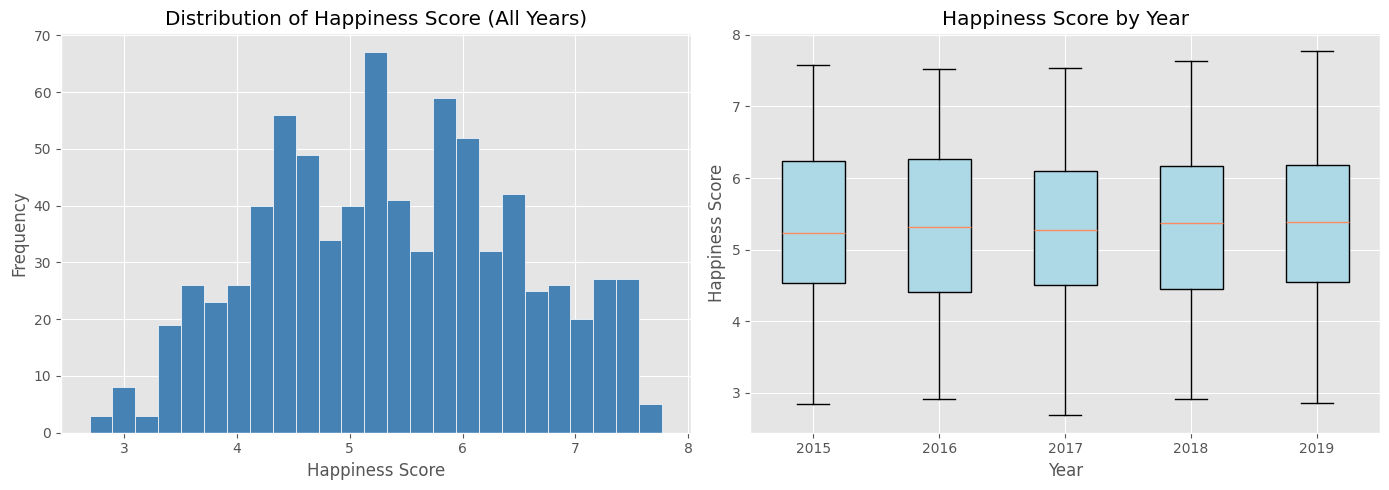

In [17]:
# Distribution of happiness scores across all years
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(df_unified['happiness_score'], bins=25, edgecolor='white', color='steelblue')
axes[0].set_title('Distribution of Happiness Score (All Years)')
axes[0].set_xlabel('Happiness Score')
axes[0].set_ylabel('Frequency')

# By year (boxplot)
year_data = [df_unified[df_unified['year'] == y]['happiness_score'] for y in sorted(df_unified['year'].unique())]
bp = axes[1].boxplot(year_data, labels=sorted(df_unified['year'].unique()), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set_title('Happiness Score by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Happiness Score')

plt.tight_layout()
plt.show()


### 6.2 Geographical Patterns

,mean,std,count
continent,,,
Oceania,7.295,0.031,10
Europe,6.144,0.923,200
America,6.119,0.762,121
Asia,5.284,0.875,230
Africa,4.294,0.660,221


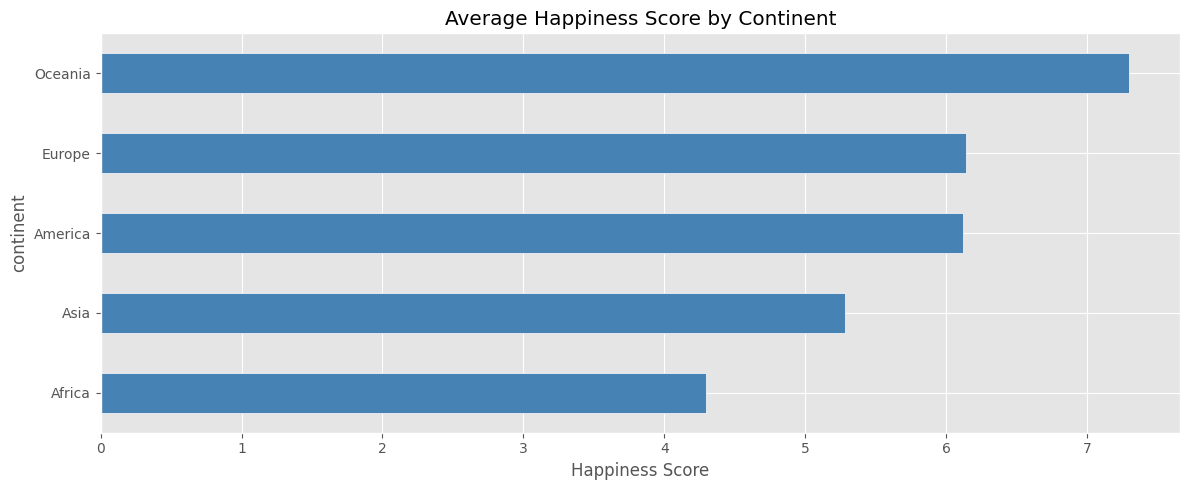

In [18]:
# Average happiness score by continent
continent_avg = df_unified.groupby('continent')['happiness_score'].agg(['mean', 'std', 'count']).round(3).sort_values('mean', ascending=False)
display(continent_avg)

# Bar plot
plt.figure(figsize=(12, 5))
avg_scores = df_unified.groupby('continent')['happiness_score'].mean().sort_values()
avg_scores.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Average Happiness Score by Continent')
plt.xlabel('Happiness Score')
plt.tight_layout()
plt.show()


In [19]:
# Interactive choropleth map
fig = px.choropleth(
    df_unified,
    locations='country',
    locationmode='country names',
    color='happiness_score',
    hover_name='country',
    animation_frame='year',
    color_continuous_scale='YlGnBu',
    title='Happiness Score by Country (2015–2019)'
)
fig.update_layout(height=500)
fig.show()


### 6.3 Top and Bottom Countries

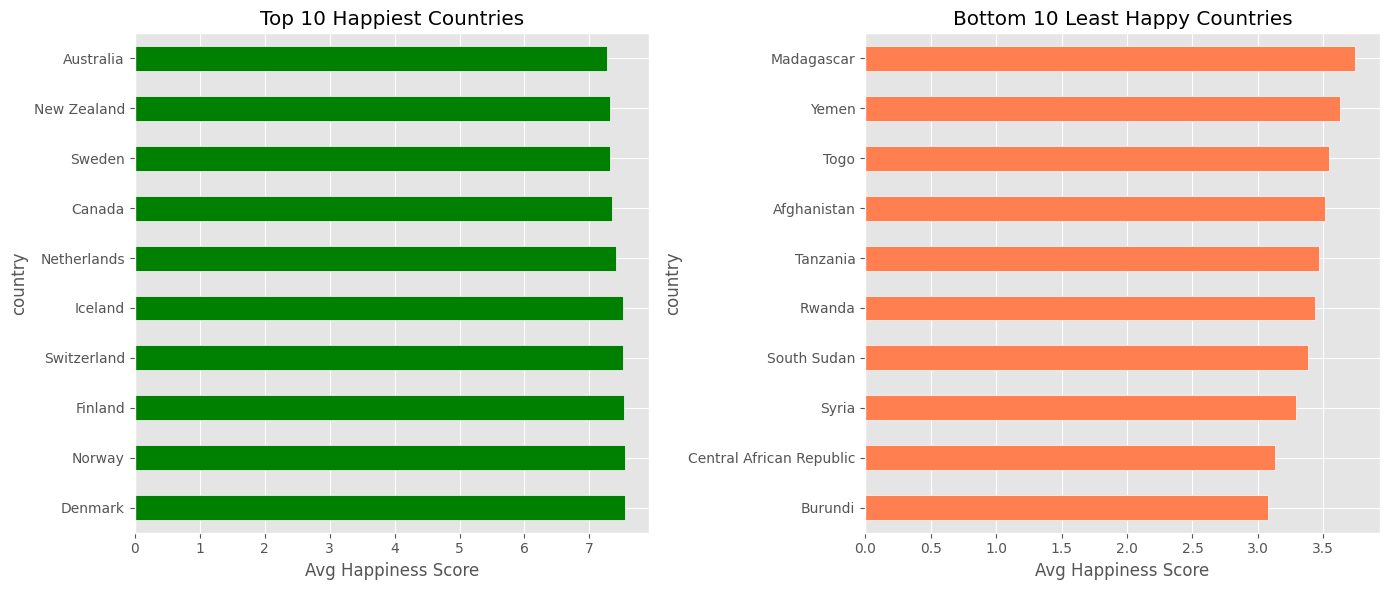

In [20]:
# Top 10 happiest countries (avg across all years)
top10 = df_unified.groupby('country')['happiness_score'].mean().sort_values(ascending=False).head(10)
bottom10 = df_unified.groupby('country')['happiness_score'].mean().sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10.plot(kind='barh', ax=axes[0], color='green', edgecolor='white')
axes[0].set_title('Top 10 Happiest Countries')
axes[0].set_xlabel('Avg Happiness Score')

bottom10.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Bottom 10 Least Happy Countries')
axes[1].set_xlabel('Avg Happiness Score')

plt.tight_layout()
plt.show()


### 6.4 Feature Distributions

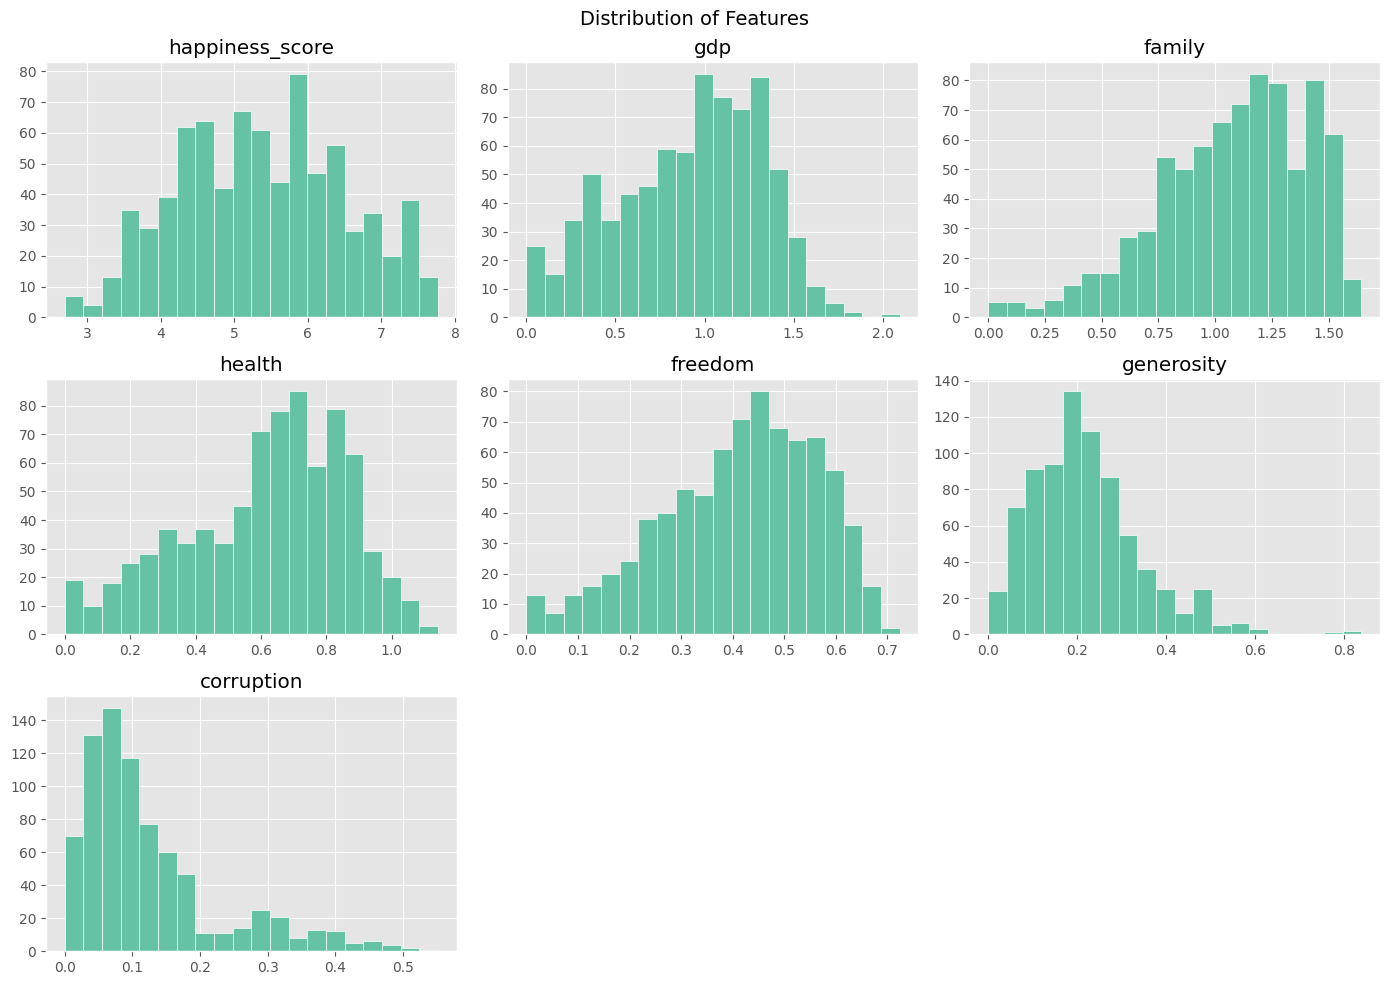

In [21]:
# Histograms of all numeric features
numeric_cols = ['happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
df_unified[numeric_cols].hist(figsize=(14, 10), bins=20, edgecolor='white')
plt.suptitle('Distribution of Features', fontsize=14)
plt.tight_layout()
plt.show()


### 6.5 Correlation Analysis

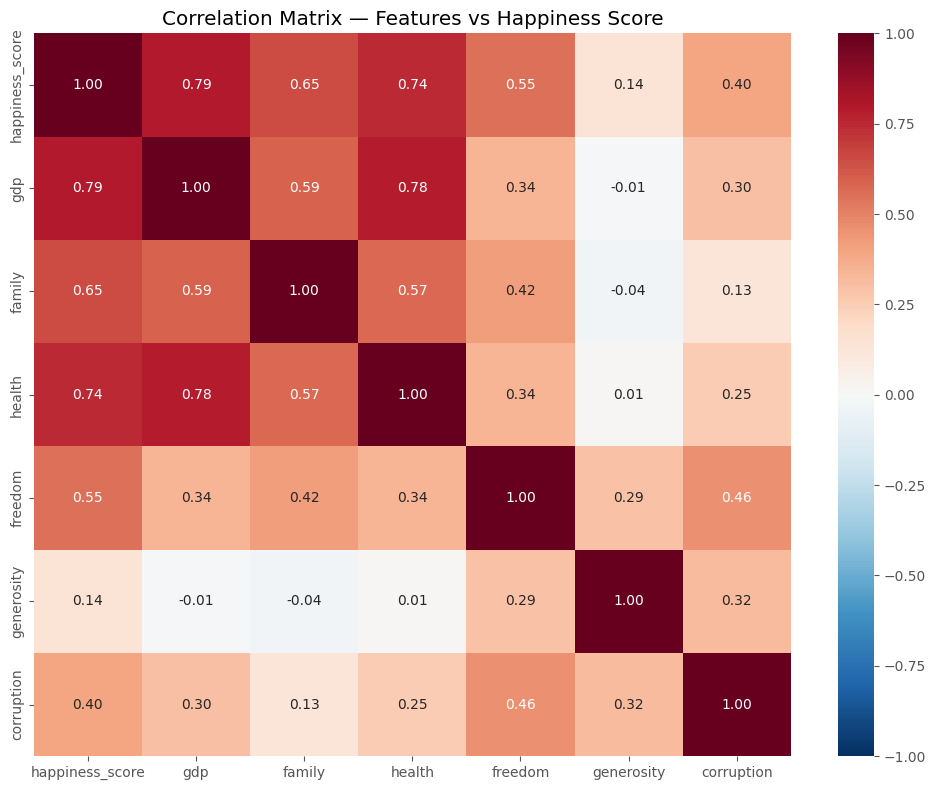

In [22]:
# Correlation matrix
corr_cols = ['happiness_score', 'gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
corr_matrix = df_unified[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Features vs Happiness Score')
plt.tight_layout()
plt.show()


### Correlation Insights:

| Feature | Correlation with Happiness | Interpretation |
|---|---|---|
| **gdp** | ~0.78 | Strong positive — richer countries tend to be happier |
| **family** (social support) | ~0.74 | Strong positive — social support matters greatly |
| **health** | ~0.72 | Strong positive — healthier populations are happier |
| **freedom** | ~0.57 | Moderate positive |
| **corruption** | ~0.34 | Weak-moderate (negative: lower corruption → higher happiness) |
| **generosity** | ~0.11 | Very weak — generosity alone doesn't predict happiness |

These correlations will guide our feature selection for modeling.


### 6.6 Feature Relationships (Scatter Plots)

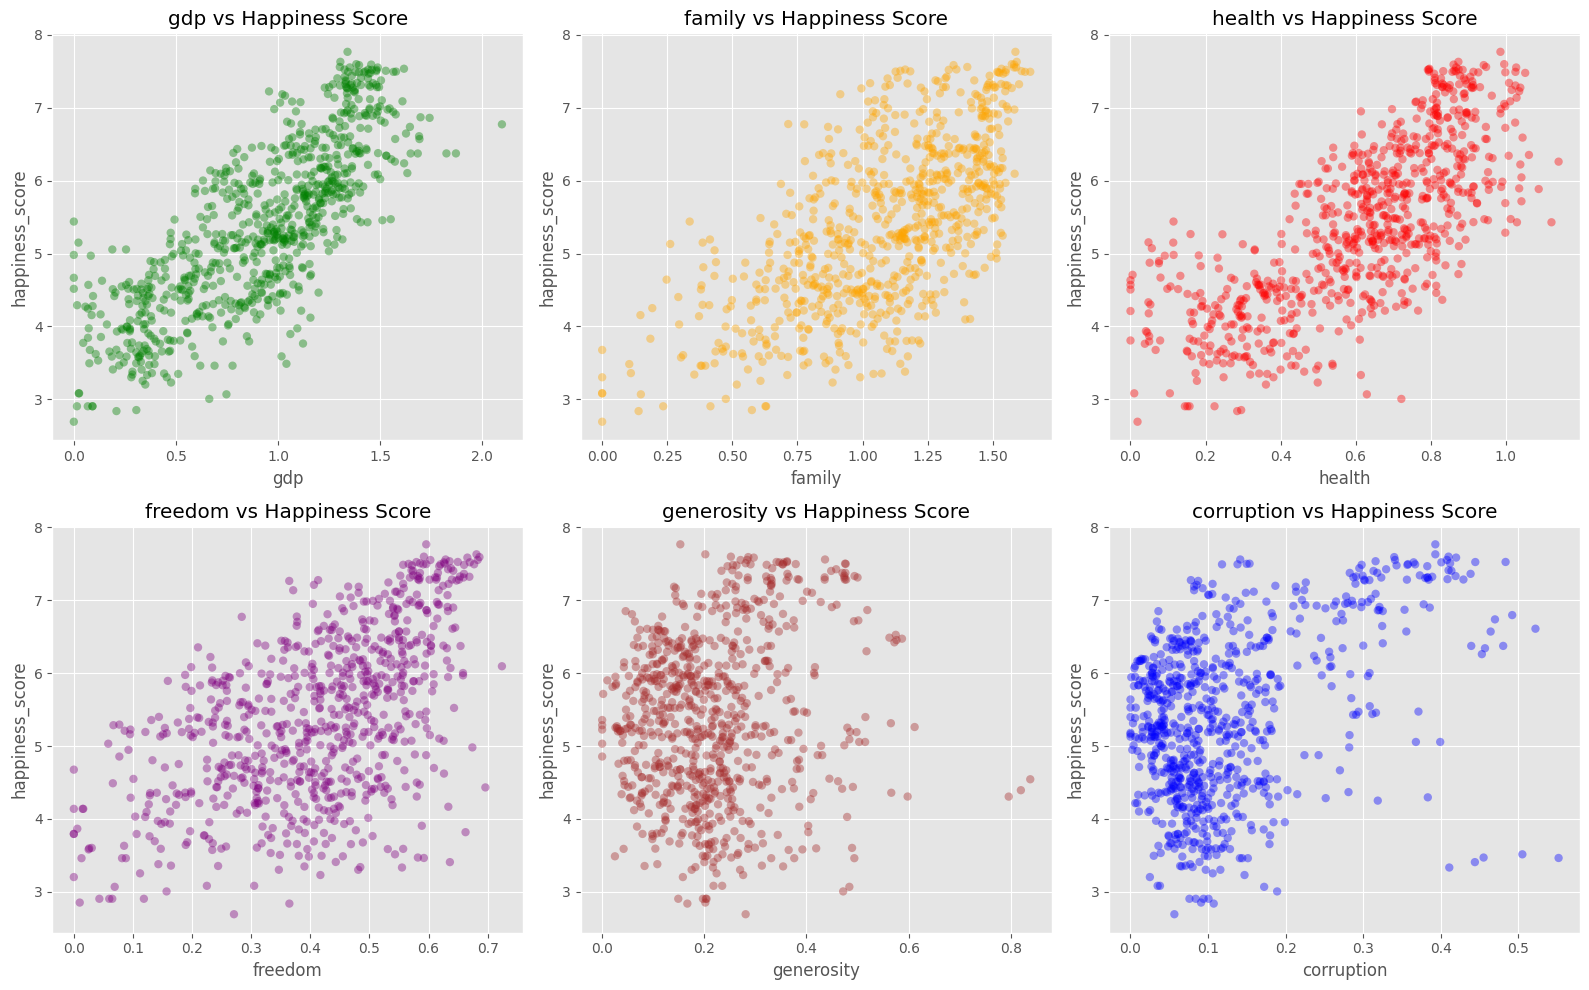

In [23]:
# Scatter plots: features vs happiness score
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['gdp', 'family', 'health', 'freedom', 'generosity', 'corruption']
colors = ['green', 'orange', 'red', 'purple', 'brown', 'blue']

for ax, feat, color in zip(axes.flatten(), features, colors):
    ax.scatter(df_unified[feat], df_unified['happiness_score'], alpha=0.4, c=color, edgecolors='none')
    ax.set_xlabel(feat)
    ax.set_ylabel('happiness_score')
    ax.set_title(f'{feat} vs Happiness Score')

plt.tight_layout()
plt.show()


### 6.7 Year-over-Year Trends

,mean,std
year,,
2015,5.3757,1.1450
2016,5.3822,1.1417
2017,5.3540,1.1312
2018,5.3759,1.1195
2019,5.4071,1.1131


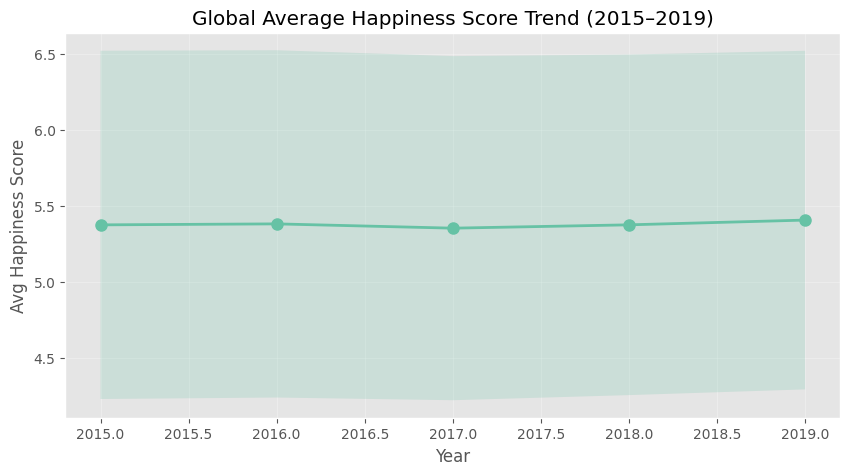

In [24]:
# Average happiness score per year
yearly_trend = df_unified.groupby('year')['happiness_score'].agg(['mean', 'std']).round(4)
display(yearly_trend)

plt.figure(figsize=(10, 5))
plt.plot(yearly_trend.index, yearly_trend['mean'], marker='o', linewidth=2, markersize=8)
plt.fill_between(yearly_trend.index, 
                 yearly_trend['mean'] - yearly_trend['std'],
                 yearly_trend['mean'] + yearly_trend['std'], 
                 alpha=0.2)
plt.title('Global Average Happiness Score Trend (2015–2019)')
plt.xlabel('Year')
plt.ylabel('Avg Happiness Score')
plt.grid(True, alpha=0.3)
plt.show()


## 7. Save Cleaned Dataset

Save the harmonized dataset for use in the model training notebook.


In [25]:
# Save to processed folder
output_path = "../data/processed/world_happiness_harmonized.csv"
df_unified.to_csv(output_path, index=False)
print(f"Saved unified dataset to {output_path}")
print(f"Final shape: {df_unified.shape}")
print(f"Years: {sorted(df_unified['year'].unique())}")
print(f"Countries: {df_unified['country'].nunique()}")


Saved unified dataset to ../data/processed/world_happiness_harmonized.csv
Final shape: (782, 11)
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Countries: 170


## Summary of Findings

### Data Quality
- **No duplicate rows** in any dataset
- **1 missing value** in 2018's corruption column (UAE) — filled with column mean
- **No major outliers** in any numeric variable
- **158 → 156 rows** per year (slight variation, expected as countries enter/exit the dataset)

### Schema Differences
- 2015–2016 include a **Region** column (lost from 2017 onward)
- 2015–2017 use different confidence measure columns (Standard Error, CI, Whisker) — dropped
- 2017 uses dot-separated column names
- 2018–2019 use entirely renamed columns (e.g., `Score` vs `Happiness Score`)
- All 9 core features exist across all years under different names

### Harmonization Results
- **782 rows** × **11 columns** (country, continent, year, happiness_rank, happiness_score, gdp, family, health, freedom, generosity, corruption)
- Continent added via `country_converter` to compensate for lost Region data

### Key Insights for Modeling
- GDP, social support (family), and health are the **strongest predictors** of happiness
- Generosity has **very weak correlation** — may not add much predictive value
- Happiness scores are **relatively stable** year-over-year (no drastic global shifts)
- Distribution is roughly **normal** with a slight left skew (more unhappy countries than very happy ones)
